[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/FFTjax/blob/main/notebooks/j2-plasticity.ipynb)

# J2 (von Mises) Plasticity

A minimal demonstration of `mat_models.plastic.J2Plasticity` (closed-form radial-return
constitutive update) and `solvers.mechanical.displacement_nw_plastic.solve_plastic_disp_nw`
(the outer Newton-CG loop that plugs it into the FFT solver), each checked against the same
independent closed-form reference: pure-shear loading, where J2 plasticity with linear isotropic
hardening reduces to a scalar problem with an exact analytic stress-strain curve.

- Elastic branch: `tau = mu * gamma`
- Plastic branch (past yield): `tau = tau_y + mu_p * (gamma - gamma_y)`, with
  `mu_p = mu * H / (3*mu + H)` the closed-form plastic shear modulus.

This is the same check used to validate the implementation in the first place -- see
`mat_models/plastic.py` and `solvers/mechanical/displacement_nw_plastic.py` for the derivation
and the additional checks (finite-difference tangent, yield-surface consistency, unloading
behaviour) that aren't repeated here to keep this notebook small.

## Setup

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running on Colab — installing FFTjax...")
    %pip install -q git+https://github.com/choROPeNt/FFTjax.git
else:
    import sys
    sys.path.insert(0, "../src")
    print("Running locally — using the local src/ checkout.")

import utils.precision  # side effect: configures JAX (X64 off on TPU, no GPU prealloc)
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from operators.green import build_freq_grid
from mat_models.plastic import J2Plasticity
from solvers.mechanical.displacement_nw_plastic import solve_plastic_disp_nw

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())
print("X64 enabled:", utils.precision.X64_ENABLED,
      "-> dtype:", jnp.zeros(1).dtype)

## Material

A steel-like J2 material with linear isotropic hardening: yield stress grows as
`sigma_y0 + H * alpha`, where `alpha` is the accumulated equivalent plastic strain.

In [2]:
material = J2Plasticity(E=210e3, nu=0.3, sigma_y0=250.0, H=1000.0, name="steel")
print(material)

mu = material.mu
gamma_y = (material.sigma_y0 / np.sqrt(3.0)) / mu           # engineering shear strain at first yield
mu_p = mu * material.H / (3.0 * mu + material.H)             # closed-form plastic shear modulus
print(f"gamma_y = {gamma_y:.4e}   mu = {mu:.1f}   mu_p = {mu_p:.1f}")

J2Plasticity (steel): E=2.1e+05, nu=0.3, sigma_y0=250, H=1000, lam=1.212e+05, mu=8.077e+04
gamma_y = 1.7870e-03   mu = 80769.2   mu_p = 332.0


## Constitutive law alone: pure shear vs. closed form

`radial_return` operates on a single material point (3x3 strain in, stress+tangent out) -- no FFT
solver involved yet. Monotonic proportional loading, so evaluating each strain level directly from
the virgin state (`eps_p_prev=0`) gives the same answer as genuine incremental stepping would.

In [3]:
gammas = np.linspace(0.0, 5 * gamma_y, 40)
tau_return_map, tau_closed_form = [], []

eps_p0, alpha0 = jnp.zeros((3, 3)), jnp.array(0.0)
for gamma in gammas:
    eps = jnp.zeros((3, 3)).at[0, 1].set(gamma / 2).at[1, 0].set(gamma / 2)
    sigma, *_ = material.radial_return(eps, eps_p0, alpha0)
    tau_return_map.append(float(sigma[0, 1]))
    tau_closed_form.append(mu * gamma if gamma <= gamma_y else mu * gamma_y + mu_p * (gamma - gamma_y))

max_err = float(np.max(np.abs(np.array(tau_return_map) - np.array(tau_closed_form))))
print("max |tau(return-map) - tau(closed-form)| :", max_err)
assert max_err < 1e-6
print("PASSED -- constitutive law matches the closed-form pure-shear curve.")

max |tau(return-map) - tau(closed-form)| : 5.684341886080802e-14
PASSED -- constitutive law matches the closed-form pure-shear curve.


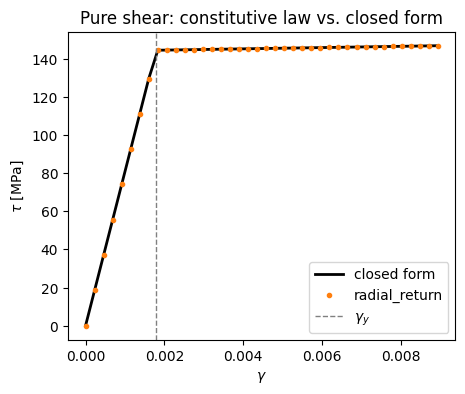

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(gammas, tau_closed_form, "k-", linewidth=2, label="closed form")
ax.plot(gammas, tau_return_map, "o", markersize=3, color="tab:orange", label="radial_return")
ax.axvline(gamma_y, color="gray", linestyle="--", linewidth=1, label=r"$\gamma_y$")
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\tau$ [MPa]")
ax.set_title("Pure shear: constitutive law vs. closed form")
ax.legend()
plt.show()

## Full FFT solver: homogeneous material, Newton-CG vs. closed form

Now solve the same pure-shear loading through the actual FFT Newton-CG solver
(`solve_plastic_disp_nw`) on a small homogeneous grid, all strain-controlled. For a homogeneous
material the local strain must equal the prescribed macroscopic strain exactly everywhere, so the
solver's output must match a single `radial_return` call exactly -- this is the same kind of
homogeneous sanity check the linear-elastic examples use, extended to plasticity.

In [5]:
n = (8, 8, 8)
L = (1.0, 1.0, 1.0)
Nv = int(np.prod(n))
xi_flat = build_freq_grid(n, L)

eps_bar = jnp.zeros((3, 3)).at[0, 1].set(gamma_y * 3 / 2).at[1, 0].set(gamma_y * 3 / 2)
control = ((0, 0, 0), (0, 0, 0), (0, 0, 0))       # pure strain BC
stress_goal = jnp.zeros((3, 3))

eps_prev = jnp.zeros((3, 3, Nv))
eps_p_prev = jnp.zeros((3, 3, Nv))
alpha_prev = jnp.zeros(Nv)

eps, sigma, eps_p, alpha, eps_bar_out, it_nw, converged_nw = solve_plastic_disp_nw(
    n, material, xi_flat, eps_bar, control, stress_goal,
    eps_prev, eps_p_prev, alpha_prev,
    toler_nw=1e-8, maxiter_nw=25, toler_lin=1e-8, maxiter_cg=2000,
)

print("Newton iterations:", it_nw, " converged:", bool(converged_nw))

sigma_ref, eps_p_ref, alpha_ref, _ = material.radial_return(eps_bar, jnp.zeros((3, 3)), jnp.array(0.0))
print("max |eps  - eps_bar|  :", float(jnp.max(jnp.abs(eps - eps_bar[:, :, None]))))
print("max |sigma - sigma_ref|:", float(jnp.max(jnp.abs(sigma - sigma_ref[:, :, None]))))
print("max |alpha - alpha_ref|:", float(jnp.max(jnp.abs(alpha - alpha_ref))))

assert bool(converged_nw)
assert float(jnp.max(jnp.abs(eps - eps_bar[:, :, None]))) < 1e-6
assert float(jnp.max(jnp.abs(sigma - sigma_ref[:, :, None]))) < 1e-3
print("\nPASSED -- FFT Newton-CG solve matches the closed-form radial return exactly.")

Newton iterations: 1  converged: True
max |eps  - eps_bar|  : 0.0
max |sigma - sigma_ref|: 0.0
max |alpha - alpha_ref|: 0.0

PASSED -- FFT Newton-CG solve matches the closed-form radial return exactly.


## Next steps

- **Heterogeneous materials**: the FFT solver's whole purpose is spatially varying material --
  see `solvers/mechanical/displacement_nw_plastic.py`'s module docstring for a worked
  elastic-inclusion / plastic-matrix sanity check (not included here to keep this notebook small;
  it currently needs a per-phase material dispatch that isn't a clean public API yet).
- **Load-stepping**: this notebook applies the target strain in a single increment. Genuine
  path-dependent loading histories need `eps_p`/`alpha` committed and carried forward between
  increments -- `scripts/simulation/pff_nw_cg_strain.py`'s timestepper loop is the template to
  adapt.
- **Hardening laws**: `H` here is linear (closed-form return map). A nonlinear hardening law
  (e.g. Voce) needs a scalar inner Newton solve for `dgamma` instead of the closed form -- still
  cheap, still per-voxel `vmap`-able, just not one line of algebra.